## Tittle: Traffic Analysis and Prediction in Owerri
#A data-driven analysis of traffic patterns and machine learning model to predict vehicle flow across different junctions.

## Executive Summary
#This project analyzes traffic data from Owerri to uncover congestion patterns and build a predictive model for vehicle volume.
#Key findings show that traffic is concentrated during specific hours and varies significantly across junctions. While the model captures general traffic trends, it struggles with extreme congestion periods due to data variability.
#The analysis demonstrates how data can support smarter urban traffic management decisions in Owerri, Imo state Nigeria.

# Statement of the problem
#Traffic sitution in owerri, the Imo State leads to delays, inefficiencies, and economic loss. Understanding traffic patterns in the state capital can help optimize transportation planning and reduce congestion by the state Government.
#This project aims to analyze traffic trends and develop a predictive model for vehicle flow in the state.

In [1]:
import pandas as pd
import numpy as np
Owerri_data = pd.read_csv(r'C:\Users\Admin\Desktop\Traffic_data\traffic.csv')


In [2]:
#Display basic information-The dataset contains traffic observations across multiple junctions in Owerri
# It include- Date time (Hour of the day,Day of the week & Months) Junction ID, Vehicle count. The dataset contains over 48,000 records.
print(Owerri_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [3]:
#Descriptive statistics of the data
print(Owerri_data.describe())

           Junction      Vehicles            ID
count  48120.000000  48120.000000  4.812000e+04
mean       2.180549     22.791334  2.016330e+10
std        0.966955     20.750063  5.944854e+06
min        1.000000      1.000000  2.015110e+10
25%        1.000000      9.000000  2.016042e+10
50%        2.000000     15.000000  2.016093e+10
75%        3.000000     29.000000  2.017023e+10
max        4.000000    180.000000  2.017063e+10


## Data Cleaning
##Checked for missing values, duplicates,invalids values etc
##Converted datetime features
## Created new features (hour, day, month)/Convert day to category/reordering 
##Encoded categorical variables

In [4]:
## Column Name Standardization
#Column names were cleaned by removing extra spaces and converting all text to lowercase to ensure consistency and prevent referencing errors during analysis
Owerri_data.columns = Owerri_data.columns.str.strip().str.lower()
print(Owerri_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   datetime  48120 non-null  object
 1   junction  48120 non-null  int64 
 2   vehicles  48120 non-null  int64 
 3   id        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [5]:
#The datetime column is converted to a proper datetime format to support time-based analysis.
Owerri_data['datetime'] = pd.to_datetime(
    Owerri_data['datetime'],
    dayfirst=True,
    errors='coerce'
)
print(Owerri_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  48120 non-null  datetime64[ns]
 1   junction  48120 non-null  int64         
 2   vehicles  48120 non-null  int64         
 3   id        48120 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.5 MB
None


In [6]:
## Data Quality Check for Missing Values
#This step identifies and summarizes missing data across all columns to assess data completeness.
Owerri_data.isnull().sum()

datetime    0
junction    0
vehicles    0
id          0
dtype: int64

In [7]:
#Check/Remove Duplicates entries in the data to improve the integrity of the data set 
Owerri_data.duplicated().sum()
print(Owerri_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  48120 non-null  datetime64[ns]
 1   junction  48120 non-null  int64         
 2   vehicles  48120 non-null  int64         
 3   id        48120 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.5 MB
None


In [8]:
#check for invalid value
Owerri_data[Owerri_data['vehicles'] < 0]
print(Owerri_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  48120 non-null  datetime64[ns]
 1   junction  48120 non-null  int64         
 2   vehicles  48120 non-null  int64         
 3   id        48120 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.5 MB
None


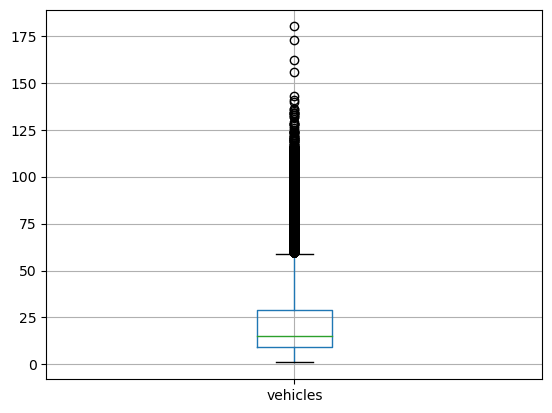

In [9]:
# check for Outlayers
import matplotlib.pyplot as plt
Owerri_data.boxplot(column='vehicles')
plt.show()

In [10]:
# Feature engineering
Owerri_data['hour'] = Owerri_data['datetime'].dt.hour
Owerri_data['day'] = Owerri_data['datetime'].dt.day_name()
Owerri_data['month'] = Owerri_data['datetime'].dt.month
Owerri_data['is_weekend'] = Owerri_data['day'].isin(['Saturday', 'Sunday'])
print(Owerri_data.head())
print(Owerri_data.info())

             datetime  junction  vehicles           id  hour     day  month  \
0 2015-11-01 00:00:00         1        15  20151101001     0  Sunday     11   
1 2015-11-01 01:00:00         1        13  20151101011     1  Sunday     11   
2 2015-11-01 02:00:00         1        10  20151101021     2  Sunday     11   
3 2015-11-01 03:00:00         1         7  20151101031     3  Sunday     11   
4 2015-11-01 04:00:00         1         9  20151101041     4  Sunday     11   

   is_weekend  
0        True  
1        True  
2        True  
3        True  
4        True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    48120 non-null  datetime64[ns]
 1   junction    48120 non-null  int64         
 2   vehicles    48120 non-null  int64         
 3   id          48120 non-null  int64         
 4   hour        48120 non-null  

In [11]:
# Convert day to category ( for purpose of performance & modeling)
Owerri_data['day'] = Owerri_data['day'].astype('category')
print(Owerri_data['day'])


0        Sunday
1        Sunday
2        Sunday
3        Sunday
4        Sunday
          ...  
48115    Friday
48116    Friday
48117    Friday
48118    Friday
48119    Friday
Name: day, Length: 48120, dtype: category
Categories (7, object): ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']


In [12]:
# reordering in a logical order (Monday, Tues, Wed ...)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

Owerri_data['day'] = pd.Categorical(
    Owerri_data['day'],
    categories=day_order,
    ordered=True
)
print(Owerri_data['day'])


0        Sunday
1        Sunday
2        Sunday
3        Sunday
4        Sunday
          ...  
48115    Friday
48116    Friday
48117    Friday
48118    Friday
48119    Friday
Name: day, Length: 48120, dtype: category
Categories (7, object): ['Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday' < 'Saturday' < 'Sunday']


In [13]:
# Assign names for the various juctions used for clearity
junction_names = {
    1: "Control Post",
    2: "Wetheral",
    3: "Ikenegbu",
    4: "IMSU Junction"
}

Owerri_data['junction_name'] = Owerri_data['junction'].map(junction_names)
Owerri_data[['junction', 'junction_name']].head()

,junction,junction_name
0,1,Control Post
1,1,Control Post
2,1,Control Post
3,1,Control Post
4,1,Control Post


In [14]:
# Convert to months names instead
Owerri_data['month_name'] = Owerri_data['datetime'].dt.month_name()
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

Owerri_data['month_name'] = pd.Categorical(
    Owerri_data['month_name'],
    categories=month_order,
    ordered=True
)
print(Owerri_data['month_name'])

0        November
1        November
2        November
3        November
4        November
           ...   
48115        June
48116        June
48117        June
48118        June
48119        June
Name: month_name, Length: 48120, dtype: category
Categories (12, object): ['January' < 'February' < 'March' < 'April' ... 'September' < 'October' < 'November' < 'December']


# Exploratory Data Analysis EDA 
our major interest here- traffic over time, traffic by hour,weekly traffic, traffic by week vs weekend, traffic by juctions, Montly trend of traffic, Pattern of traffic by juction


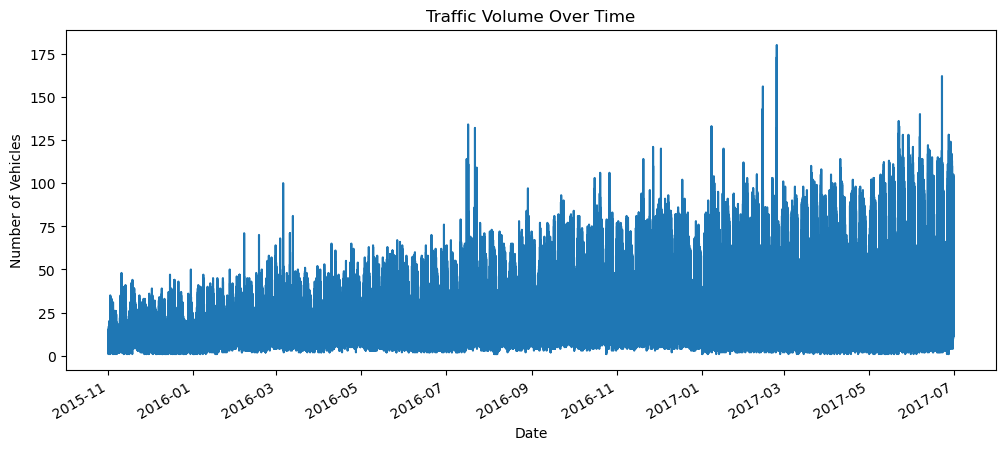

In [15]:
# EDA analysis ( Traffic trend over time) my major interest here is if there is an Upward or downward trends, Seasonal patterns, Sudden spikes (events, anomalies))
import matplotlib.pyplot as plt

Owerri_data.set_index('datetime')['vehicles'].plot(figsize=(12,5))
plt.title("Traffic Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Vehicles")
plt.show()

# Interpretation 
The Time Series plot shows the variation in traffic volume (number of vehicles) from late 2015 to mid-2017.

## Key Insights
The plot shows Overall Upward Trend of trafffic over time from 2015-2017 i.e traffic volume generally increases over time
In early 2016, most traffic counts were below 50 vehicles, while by 2017 many observations exceed 100 vehicles.
This suggests growing road usage, increasing urban activity, or population/transport expansion over the period under review.
The plot also shows frequent rises and falls, indicating traffic is not constant and most likely affected by
peak/off-peak hours,
weekdays vs weekends,
seasonal events,
weather or road conditions.

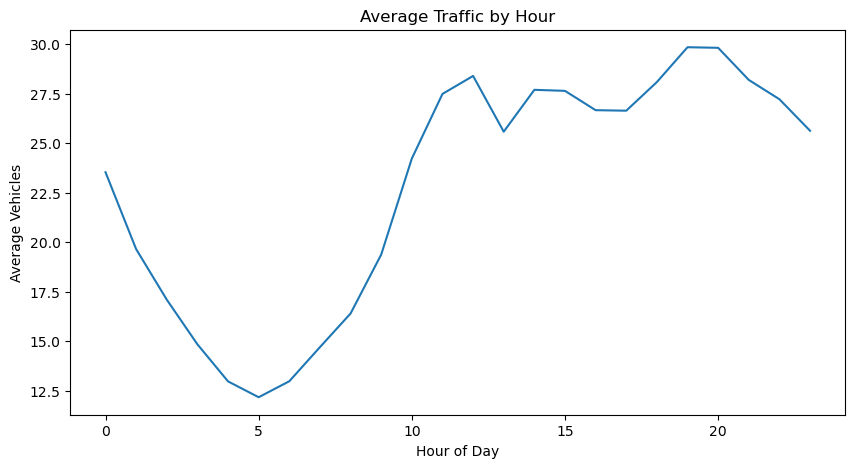

In [16]:
#Traffic by Hour (Peak Hours)
Owerri_data.groupby('hour')['vehicles'].mean().plot(kind='line', figsize=(10,5))
plt.title("Average Traffic by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicles")
plt.show()

# Interpretation
This line plot displays the average number of vehicles recorded at each hour of the day, showing how traffic volume changes over a 24-hour period.The plot shows that traffic volume follows a clear daily pattern. Vehicle movement is relatively low during the early morning hours, reaching its minimum around 5 AM. After this point, traffic gradually increases as daily activities begin.
A sharp rise in traffic is observed from the morning period into the afternoon, indicating increased commuting and commercial activities. Traffic remains consistently high throughout the daytime and reaches its peak in the evening period around 7 PM to 8 PM.
After the evening peak, traffic volume begins to decline gradually toward nighttime. This pattern suggests strong time-dependent behavior, meaning traffic volume is highly influenced by the hour of the day.

# Key insights
Lowest traffic occurs around 5 AM: Average traffic drops to about 12 vehicles, indicating minimal road activity.
Traffic increases rapidly after morning hours- Vehicle movement rises significantly after 6–9 AM as people begin daily activities.
Daytime traffic remains consistently high
Between late morning and evening, traffic averages above 25 vehicles.
Peak congestion occurs around 7–8 PM
This represents the busiest traffic period of the day.
Traffic declines gradually at night
After the evening rush hour, traffic volume steadily reduces.

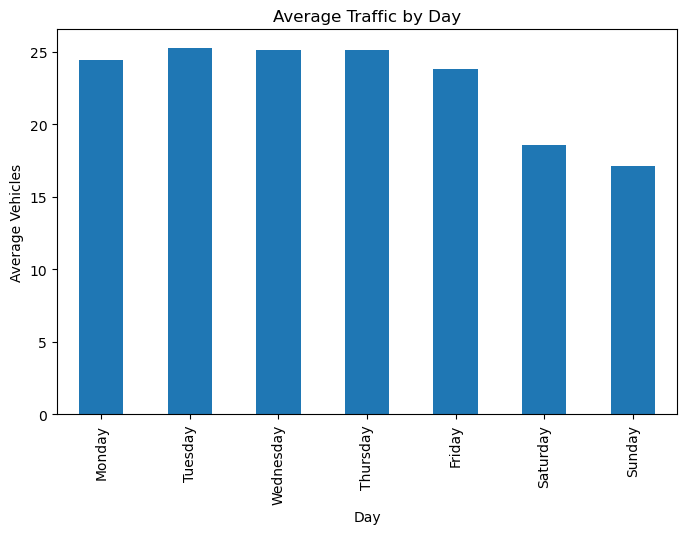

In [17]:
#Traffic by Day of Week
Owerri_data.groupby('day')['vehicles'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Traffic by Day")
plt.xlabel("Day")
plt.ylabel("Average Vehicles")
plt.show()

# Interpretation
A bar chat showing averhe traffic pattern by the day of the week- Monday through Sunday
The plot indicates that traffic volume varies noticeably across different days of the week. Weekdays generally experience higher average traffic compared to weekends.

Among the weekdays, Tuesday, Wednesday, and Thursday record the highest traffic volumes, each averaging around 25 vehicles, while Monday and Friday also show relatively high traffic levels, though slightly lower than the midweek days.

In contrast, weekends experience reduced traffic activity. Saturday and Sunday have the lowest average traffic volumes, with Sunday recording the minimum value of approximately 17 vehicles.

The pattern suggests that traffic movement is strongly influenced by work-related, educational, and commercial activities that are more active during weekdays and reduced during weekends

# Key Insights
-Weekdays experience higher traffic than weekends:traffic activity is consistently greater from Monday to Friday.
-Tuesday to Thursday are the busiest days: these days record the highest average vehicle counts, around 25 vehicles.
-Sunday has the lowest traffic volume: the average traffic drops to approximately 17 vehicles, indicating reduced movement and commercial activity.
-Weekend traffic declines significantly:both Saturday and Sunday show noticeably lower traffic compared to weekdays.
-Traffic pattern reflects human activity cycles: the variation likely corresponds to work schedules, school operations, and business activities.

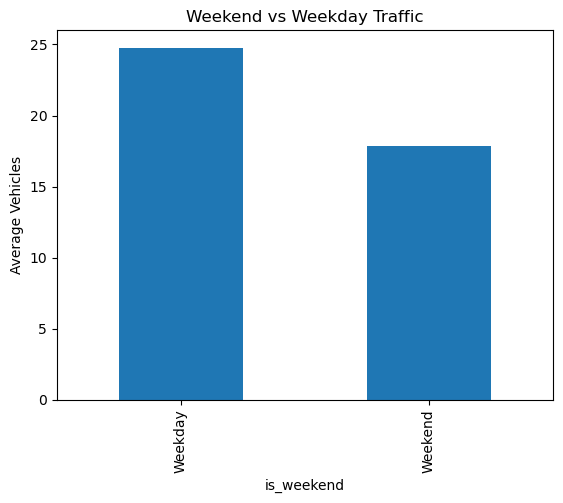

In [18]:
#Weekend vs Weekday
Owerri_data.groupby('is_weekend')['vehicles'].mean().plot(kind='bar')
plt.title("Weekend vs Weekday Traffic")
plt.xticks([0,1], ['Weekday', 'Weekend'])
plt.ylabel("Average Vehicles")
plt.show()

# Weekend vs Weekday Traffic

## Interpretation
The chart shows a comparison between average traffic volumes on weekdays and weekends. It is observed that weekday traffic is significantly higher, averaging around 25 vehicles, while weekend traffic drops to approximately 18 vehicles. This indicates a clear variation in traffic patterns based on the day type.
The higher weekday traffic suggests increased movement due to work, school, and business-related activities, whereas weekends experience reduced traffic likely due to fewer routine obligations.

## Key Insights
-Weekday traffic is approximately 35–40% higher than weekend traffic.
-Traffic demand is strongly driven by weekday economic and social activities.
-Weekends represent off-peak traffic periods.

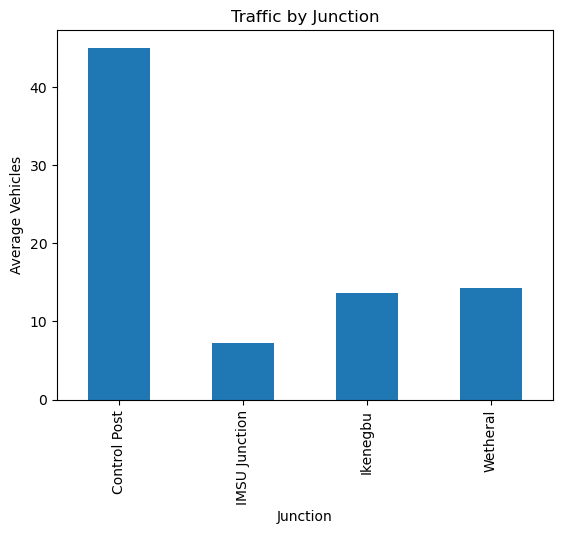

In [19]:
# Traffic by Junction First by names
Owerri_data.groupby('junction_name')['vehicles'].mean().plot(kind='bar')
plt.title("Traffic by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Vehicles")
plt.show()

# Traffic by Junction

## Interpretation
The bar chart compares average traffic volumes across different junctions in owerri. Control busstop(junction) records the highest traffic volume by a wide margin, while IMSU Junction has the lowest. Ikenegbu and Wetheral fall in the middle range with moderate traffic levels.
This indicates that traffic is unevenly distributed across locations, with certain junctions acting as major traffic hubs in owerri metropolice.

## Key Insights
-Control Post is a major traffic hotspot with significantly higher volume than other junctions.
-Traffic distribution is uneven, suggesting possible congestion at key points.
-IMSU Junction experiences very low traffic, indicating lower usage or connectivity.
-Location (junction) is a critical feature for traffic prediction models.
-Traffic management strategies can focus on redistributing flow from congested areas.

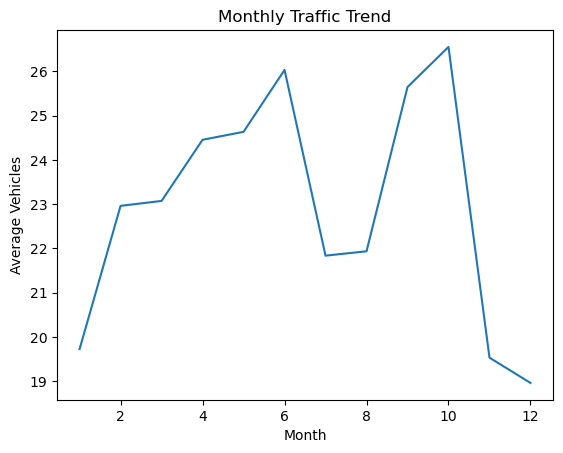

In [20]:
#Monthly Trend
Owerri_data.groupby('month')['vehicles'].mean().plot(kind='line')
plt.title("Monthly Traffic Trend")
plt.xlabel("Month")
plt.ylabel("Average Vehicles")
plt.show()

# Monthly Traffic Trend

## Interpretation
The line chart illustrates how traffic volume changes across the months of the year. Traffic starts relatively low in January, gradually increases to a peak around June, then drops sharply in July. Afterward, it rises again to another peak in October before declining significantly toward November and December.
The fluctuation indicates that traffic volume is not constant throughout the year but varies due to seasonal or temporal factors.

## Key Insights
-Traffic exhibits clear seasonal patterns with peaks in June and October.
-A noticeable dip occurs in July, possibly due to mid-year breaks or reduced activity.
-Traffic declines toward the end of the year, indicating lower movement during that period.
-The month variable is important for capturing seasonality in predictive models.
-Incorporating seasonal features can improve model performance.

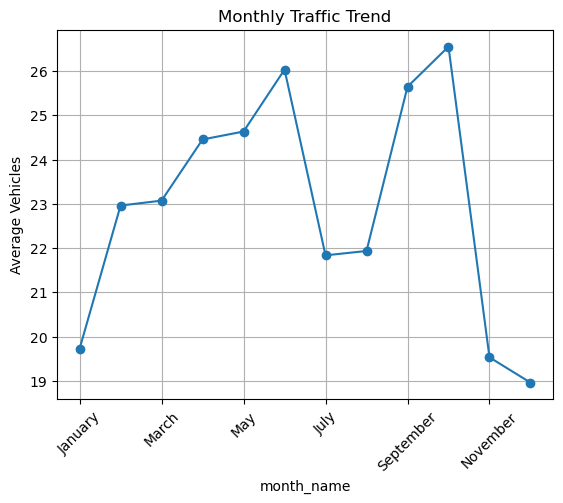

In [21]:
# Monthly Trend by name
monthly_trend = Owerri_data.groupby('month_name', observed=True)['vehicles'].mean()
monthly_trend.plot(kind='line', marker='o')

plt.title('Monthly Traffic Trend')
plt.xlabel('month_name')
plt.ylabel('Average Vehicles')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

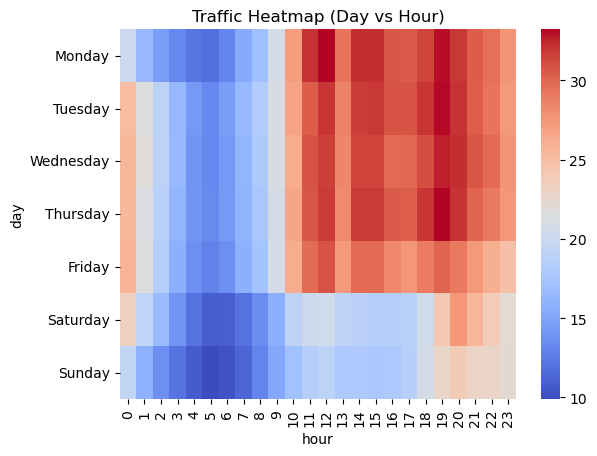

In [22]:
#ADVANCED VISUALIZATION  A. Heatmap (Hour vs Day)

import seaborn as sns

pivot = Owerri_data.pivot_table(
    values='vehicles',
    index='day',
    columns='hour',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='coolwarm')
plt.title("Traffic Heatmap (Day vs Hour)")
plt.show()

# Traffic Heatmap Analysis (Day vs Hour)

## Interpretation

The heatmap illustrates traffic volume distribution across different days of the week and hours of the day. Color intensity represents traffic levels, with cooler colors (blue) indicating low traffic and warmer colors (red) indicating high traffic.

#### Daily Traffic Pattern
Traffic trends are generally consistent across weekdays (Monday to Friday), showing a structured and predictable flow. In contrast, weekends (Saturday and Sunday) display lower and more evenly distributed traffic levels.

#### Early Morning (00:00 – 06:00am)
Traffic is at its lowest during the early hours of the day across all days. This reflects minimal movement, likely due to reduced commuting and economic activity.

#### Morning Build-Up (06:AM – 10:AM)
Traffic begins to increase gradually from around 6 AM. This period reflects the start of daily routines such as going to work, school runs, and business activities. The increase is more pronounced on weekdays.

#### Midday to Evening Peak (11:AM – 20:PM)
Traffic reaches its highest levels between late morning and evening. Two major peaks are noticeable:
-Midday peak (12:Noon – 14:PM)
-Evening peak (17:PM – 20:PM)
These peaks are strongest on weekdays, indicating structured urban commuting patterns.

#### Night Decline (21:PM – 23:PM)
Traffic begins to decline after 8 PM, transitioning to moderate levels as daily activities wind down.

#### Weekend Pattern
Weekend traffic is less intense and more evenly spread throughout the day. There are no sharp peaks, suggesting reduced work-related travel and more flexible movement patterns.


# Key Insights

#### Peak Traffic Periods
The highest traffic volumes occur between 12:00 and 20:00, with the most critical congestion during evening hours (17:00 – 20:00).

#### Weekday vs Weekend Difference
Weekdays experience significantly higher and more structured traffic compared to weekends, which show lower and flatter patterns.

#### Predictable Traffic Cycle
Traffic follows a consistent daily cycle:
-Low: Midnight to early morning
-Increasing: Morning hours
-Peak: Afternoon to evening
-Declining: Night
This predictability is useful for traffic forecasting and modeling.

#### Low-Traffic Windows
The least congested period is between 00:00 and 06:00. This is ideal for:
-Road maintenance
-Logistics and delivery operations which inline with government no-entry truck policy until 11pm in owerri

#### Strong Evening Congestion
Evening traffic peaks are more intense than morning increases, suggesting higher outbound movement and possible accumulation of delays during the day.

#### Indicator of Urban Activity
Traffic patterns closely reflect economic and social activity:
-High during working hours
-Lower during rest periods and weekends

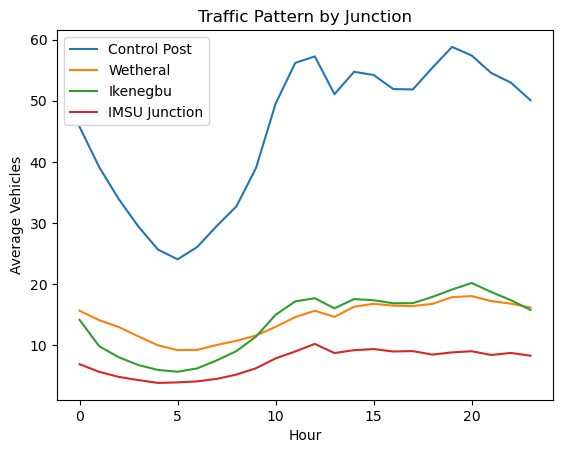

In [23]:
for j in Owerri_data['junction_name'].unique():
    subset = Owerri_data[Owerri_data['junction_name'] == j]
    
    hourly_avg = subset.groupby('hour')['vehicles'].mean()
    
    plt.plot(hourly_avg.index, hourly_avg.values, label=j)

plt.legend()
plt.title("Traffic Pattern by Junction")
plt.xlabel("Hour")
plt.ylabel("Average Vehicles")
plt.show()

# Traffic Pattern Analysis by Junction

## Interpretation
The traffic pattern across the four junctions—Control Post, Wetheral, Ikenegbu, and IMSU—shows clear temporal variations over the 24-hour period.

-**Control Post** experiences the highest traffic volume throughout the day. Traffic declines steadily from midnight (around 45 vehicles) to an early morning low (around 24 vehicles at 5 AM), indicating reduced movement during late-night/early morning hours. From 6 AM onward, traffic rises sharply, peaking between late morning and evening (around 55–59 vehicles), before slightly declining at night.

-**Wetheral Junction** shows moderate traffic levels. It starts relatively higher at midnight (16 vehicles), dips in the early morning (9 vehicles), and gradually increases through the day, peaking in the evening (18 vehicles). This suggests steady but less intense traffic flow compared to Control Post.

-**Ikenegbu Junction** follows a similar pattern to Wetheral but with slightly higher daytime peaks. Traffic is lowest in the early morning (6 vehicles), then rises significantly from mid-morning, reaching its peak (~20 vehicles) in the evening hours before declining slightly.

-**IMSU Junction** consistently records the lowest traffic volume. Traffic is minimal in the early morning (~4 vehicles), increases gradually during the day, and peaks modestly (9–10 vehicles) in the afternoon and evening. This indicates a relatively low-traffic area with mild daily fluctuations.

Overall, all junctions exhibit a **morning buildup, daytime peak, and slight evening decline**, reflecting typical urban traffic behavior.


## Key Insights

-**Control Post is the busiest junction**, with traffic volumes significantly higher than all other locations throughout the day.

-**Peak traffic period across all junctions occurs between 10 AM and 8 PM**, indicating high daytime economic and social activity known for owerri municipal.

-**Early morning hours (2 AM – 6 AM) show the lowest traffic across all locations**, making it the least congested period.

-**Ikenegbu and Wetheral junctions have similar traffic patterns**, but Ikenegbu experiences slightly higher peak volumes, suggesting it may be a more active route.

-**IMSU Junction consistently has the lowest traffic**, indicating it is less critical in overall traffic flow or serves a smaller population.

-**Traffic increases sharply after 6 AM**, highlighting the start of daily business activities.

-**Evening traffic remains relatively high**, especially at Control Post and Ikenegbu, suggesting sustained movement beyond typical work hours.


# Summary of Key Insights
-Traffic volume shows a clear upward trend over time, with increasing congestion intensity and more frequent extreme traffic spikes in 2017.
-Traffic is low between 4-5 AM in the morning hours and increase through the day and at peaks in evennig (5-8PM)
-Traffic is highest on weekdays especially Tuesday to Thursday and drops significantly during the weekend, with Sunday recording the lowest traffic volume
-Traffic peaks mid-year, dips in July–August, rebounds in September–October, then declines toward the end of the year
-Traffic is lowest in the early morning hours and peaks consistently from late morning to evening, especially during weekdays.
- The Control Post junction experiences significantly heavier traffic than all other junctions, with sharp increases from around 10 AM through the evening hours.


## Conclusion: Owerri Traffic Pattern

The analysis of traffic patterns in Owerri reveals a structured and predictable flow influenced by time of day, day of the week, and seasonal variations.
-Traffic volume demonstrates a **progressive upward trend over time**, indicating increasing congestion levels and a growing transportation demand within the city. This is further reinforced by the presence of **more frequent extreme traffic spikes**, particularly in recent periods.
-On a daily scale, traffic is **lowest during the early morning hours (especially 4–5 AM)** and begins to rise steadily as the day progresses. Peak congestion consistently occurs in the **evening hours (5–8 PM)**, reflecting typical work commute patterns.
-Weekly patterns show that **traffic is highest on weekdays**, particularly from **Tuesday to Thursday**, while there is a **significant decline during weekends**, with **Sunday recording the lowest traffic volume**. This highlights the strong influence of economic and business activities on traffic flow.
-Seasonally, traffic exhibits fluctuations, with **peak activity observed mid-year**, a **decline during July–August**, a **rebound in September–October**, and a **gradual reduction toward the end of the year**. These variations may be linked to holidays, weather conditions, or institutional calendars.
-Across locations, the **Control Post junction stands out as the most congested point**, experiencing significantly higher traffic volumes than other junctions. It shows sharp increases from late morning through the evening, making it a critical hotspot for traffic management interventions.
Overall, Owerri’s traffic pattern is **time-dependent, activity-driven, and location-sensitive**, with clear peak periods and congestion hotspots. These findings provide a strong basis for **traffic planning, congestion control strategies, and infrastructure development**, particularly focusing on peak hours, busy weekdays, and high-traffic junctions like Control Post.


# From Analysis to Prediction
Based on the observed traffic patterns, we now develop a machine learning model to predict vehicle volume using time and location features.
prepare data for machine learning
## Encoding Categorical Variables
Categorical features such as **day**, **month_name**, and **junction_name** are converted into numerical format using one-hot encoding.
-We use `pd.get_dummies()` to:
-enable machine learning models to process categorical data
-Avoid introducing false ordinal relationships between categories
The `drop_first=True` option is applied to prevent multicollinearity.
A model that predicts: vehicles (traffic volume) based on:Hour,Day,Month & Junction

In [24]:
features = ['hour','month', 'junction']
X = Owerri_data[features]

y = Owerri_data['vehicles']

X = pd.get_dummies(Owerri_data[['hour','month','junction','day']], drop_first=True)
y = Owerri_data['vehicles']


In [25]:
X.head()

,hour,month,junction,day_Tuesday,day_Wednesday,day_Thursday,day_Friday,day_Saturday,day_Sunday
0,0,11,1,False,False,False,False,False,True
1,1,11,1,False,False,False,False,False,True
2,2,11,1,False,False,False,False,False,True
3,3,11,1,False,False,False,False,False,True
4,4,11,1,False,False,False,False,False,True


In [26]:
X.columns

Index(['hour', 'month', 'junction', 'day_Tuesday', 'day_Wednesday',
       'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday'],
      dtype='object')

In [27]:
X.shape

(48120, 9)

In [28]:
X.dtypes


hour             int32
month            int32
junction         int64
day_Tuesday       bool
day_Wednesday     bool
day_Thursday      bool
day_Friday        bool
day_Saturday      bool
day_Sunday        bool
dtype: object

## Model Development
# A regression model was developed to predict traffic volume.
# From Analysis to Prediction
#Based on the observed traffic patterns, we now develop a machine learning model to predict vehicle volume using time and location features.

## Train-Test Split
The dataset was divided into training and testing subsets to evaluate the model's performance on unseen data.
- **Training Set (80%)**: Used to train the model and learn underlying patterns in the data.  
- **Testing Set (20%)**: Used to assess the model’s predictive performance and generalization ability.

In [29]:
#Split Data (Train vs Test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [30]:
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (38496, 9) (38496,)
Test set: (9624, 9) (9624,)


In [31]:
# Train the model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [32]:
# Make Predictions
y_pred = model.predict(X_test)

In [33]:
print("First 5 Predictions:", y_pred[:5])
print("First 5 Actual Values:", y_test.values[:5])

First 5 Predictions: [15.72546429 22.50125079 12.6700368  19.53852381 20.02124306]
First 5 Actual Values: [11 28 34 21 13]


# Model Evaluation

The performance of the model was evaluated using standard regression metrics to measure prediction error on the test dataset.
- **Mean Absolute Error (MAE)**: Measures the average magnitude of errors in predictions, without considering direction.
- **Mean Squared Error (MSE)**: Measures the average squared difference between predicted and actual values, penalizing larger errors more heavily.

In [34]:
#Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 8.264553059777334
MSE: 149.41580012432746


## Model Evaluation

The model was evaluated using Mean Absolute Error (MAE) and Mean Squared Error (MSE).
- **MAE:** 8.37  
- **MSE:** 149.68  

## Interpretation

The MAE of 8.37 indicates that, on average, the model’s predictions deviate from actual traffic values by about vehicles units. The MSE of 149.68 suggests the presence of some larger errors, as it penalizes big deviations more heavily.

# Insights
The model performs reasonably well in capturing general traffic flow patterns in Owerri.
However, the relatively higher MSE indicates that peak traffic periods such rush hours (e.g school hours) market days, or congestion caused by events are not consistently predicted accurately.
This is common in traffic datasets because traffic behavior is non-linear and influenced by external factors such as road usage patterns, time of day, and events

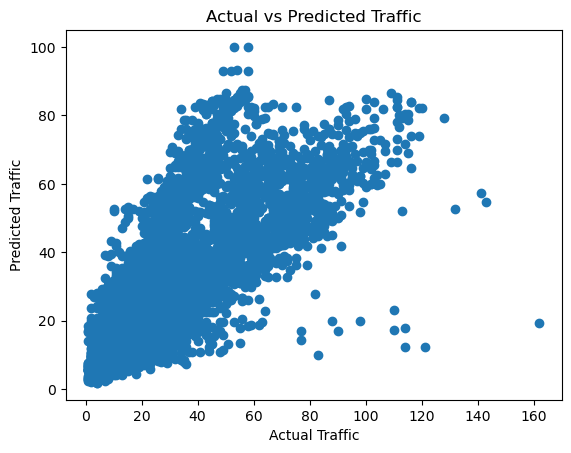

In [35]:
#Visualization
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Traffic")
plt.ylabel("Predicted Traffic")
plt.title("Actual vs Predicted Traffic")
plt.show()

## Actual vs Predicted Traffic

This plot compares the actual traffic values with the model’s predicted values to assess how well the model captures traffic patterns in Owerri.

## Interpretation

The scatter plot shows a positive relationship between actual and predicted traffic values, indicating that the model is able to learn the general trend in the traffic data. However, the points are widely dispersed around the ideal prediction line, suggesting the posssible presence of prediction errors.

The model performs better at lower to moderate traffic levels, where predictions appear more consistent. At higher traffic levels, the spread increases, indicating reduced accuracy.

## Insight (Owerri Traffic Context)

The model captures general traffic flow patterns in owerri but struggles with accurately predicting high traffic conditions. This suggests that peak congestion periods in Owerri may be influence by extenal factors such as rush hours, market activities, and road conditions.


## Conclusion

Overall, the model demonstrates good trend prediction ability but shows limitations in accurately forecasting high traffic volumes, indicating a need for further improvement for real-world traffic management applications.

# Feature Importance Analysis (Post-Prediction)

After training and generating predictions from the model, we analyze feature importance to understand which variables had the most influence on the model’s predictions.
This will help to improve model interpretability and provides insights into the most influential factors driving the traffic pattern in owerri, Imo State.

## Extracting Feature Importance

The feature importance was extracted from the trained model using its built-in attribute


Feature Importance:

day_Wednesday    0.005546
day_Tuesday      0.005800
day_Thursday     0.005838
day_Friday       0.006310
day_Sunday       0.032450
day_Saturday     0.034281
month            0.071658
hour             0.183342
junction         0.654775
dtype: float64


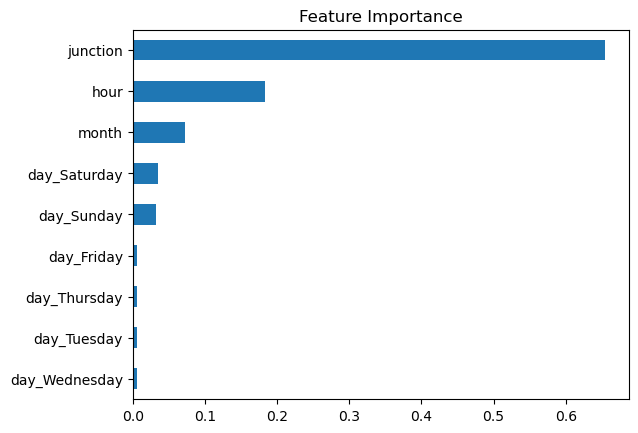

In [36]:
# Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance_sorted = importance.sort_values()

print("Feature Importance:\n")
print(importance_sorted)

importance_sorted.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

# Feature Importance Analysis Report

It shows contribution of each variables contribute to a machine learning model’s predictions. The relationships provides valuable insights into the key drivers influencing the target variable.

# Key Insights

## Junction is the Most Influential Feature

### Observation
The feature `junction` has the highest importance score, contributing approximately **65%** of the model's predictive power.

### Interpretation
The result indicates that location-based characteristics strongly influence the model output. Different junctions likely exhibit distinct traffic behaviors due to:
-Road structure differences
-Traffic volume variations
-Population density
-Nearby commercial activities
-Signal timing differences

### Key Insight
The model relies primarily on spatial patterns rather than temporal or calendar-based variables.

### Practical Implication
Improving or optimizing specific junctions could significantly affect traffic performance or prediction accuracy.
Potential actions include:
-Traffic light optimization
-Junction redesign
-Road expansion
-Dedicated traffic lanes
-Improved monitoring systems

## Hour of the Day is the Second Most Important Feature

### Observation
The feature `hour` contributes approximately **19%** to the model predictions.

### Interpretation
Traffic conditions vary significantly depending on the time of day.
This reflects:
-Morning rush hours
-Evening congestion
-Work commuting patterns
-School transportation schedules
-Reduced nighttime traffic

### Key Insight
Temporal behavior plays a major role in traffic dynamics.

### Practical Implication
Traffic management systems should adapt dynamically based on time.

Examples include:
-Time-based traffic signal control
-Peak-hour routing strategies
-Dynamic congestion management
-Real-time traffic monitoring


## Month Has Moderate Importance

### Observation
The feature `month` contributes around **7%** to the overall prediction model.

### Interpretation
Seasonal patterns moderately influence traffic behavior.

Possible reasons may include:
-Weather changes
-Public holidays
-Festive periods
-School calendars
-Seasonal travel patterns

### Key Insight
Although seasonal effects exist, they are less influential compared to junction and hourly patterns in traffic model prediction in owerri municipal.

### Practical Implication
Long-term forecasting models should still account for seasonal variations.


# Day-of-Week Features Have Minimal Impact

### Observation
Features representing days of the week:
- `day_Saturday`
- `day_Sunday`
- `day_Friday`
- `day_Thursday`
- `day_Wednesday`
- `day_Tuesday`
Day of the week have very low importance values.

### Interpretation
The model suggests that weekday differences do not significantly affect predictions compared to:
-Location (`junction`)
-Time (`hour`)

### Key Insight
Traffic behavior appears more dependent on where and when traffic occurs rather than the exact weekday.

### Practical Implication
Simplifying weekday variables may not substantially reduce model performance.


# Overall Findings

The model is primarily driven by:

1. **Spatial Factors**
   - Junction/location characteristics dominate predictions.

2. **Temporal Factors**
   - Hourly traffic patterns strongly influence outcomes.

3. **Seasonal Factors**
   - Monthly variations contribute moderately.

4. **Weekly Patterns**
   - Weekday-specific effects are relatively insignificant.


# Business and Operational Insights

## High-Impact Areas
Organizations should prioritize:
-Critical junctions
-Peak traffic hours
rather than allocating equal attention to all locations or weekdays.

# Recommendations

## Model Improvement Recommendations

### 1. Add More Spatial Features
Possible additions:
-Road type
-Number of lanes
-Nearby landmarks
-Population density

### 2. Improve Temporal Feature Engineering
Additional features may include:
-Rush hour indicator
-Weekend indicator
-Holiday indicator
-Peak/off-peak classification

### 3. Incorporate External Factors
Additional datasets could improve performance:
-Weather conditions
-Public events
-Accident reports
-Road construction activities

### 4. Analyze High-Importance Junctions
Conduct deeper investigations into highly influential junctions to understand:
-Congestion causes
-Traffic bottlenecks
-Infrastructure limitations


# Conclusion

The feature importance analysis reveals that the model heavily depends on:
-Junction-specific patterns
-Hourly traffic behavior

while seasonal and weekday effects play comparatively smaller roles.

These insights can guide:
-Traffic optimization strategies by relavant traffic management agencies 
-Infrastructure planning by the state 
-Smart transportation systems
-Predictive traffic management solutions

In [37]:
import os
print(os.getcwd())

C:\Users\Admin
